## STATUS: DISCARDED - TRY

Attempted to use a Variational Autoencoder (VAE) to generate synthetic playlists and balance the dataset. The probabilistic generation created blurry data boundaries, causing Macro-F1 to drop to 25.3%. Replaced by SMOTE.

In [1]:
# ============================================
# AUTOENCODER TRAINING FOR MBTI CLASSIFIER
# ============================================

import numpy as np
import pandas as pd
import os
import pickle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Define paths
BASE_PATH = '/content/drive/MyDrive/mbti-tune'
CLEANED_PATH = f'{BASE_PATH}/data/cleaned'
MODELS_PATH = f'{BASE_PATH}/models'
os.makedirs(MODELS_PATH, exist_ok=True)

print("="*80)
print("AUTOENCODER TRAINING FOR MBTI CLASSIFIER")
print("="*80)

Mounted at /content/drive
AUTOENCODER TRAINING FOR MBTI CLASSIFIER


In [2]:
# ============================================
# 1. LOAD DATA
# ============================================

print("\n" + "="*50)
print("1. LOADING DATA")
print("="*50)

# Load master features
with open(f'{CLEANED_PATH}/master_features.pkl', 'rb') as f:
    MASTER_FEATURES = pickle.load(f)

# Load scaled data
X_1m = np.load(f'{CLEANED_PATH}/autoencoder/X_1m_scaled.npy')
X_110k = np.load(f'{CLEANED_PATH}/autoencoder/X_110k_scaled.npy')
X_mbti = np.load(f'{CLEANED_PATH}/classifier/X_mbti_scaled.npy')
y_mbti = np.load(f'{CLEANED_PATH}/classifier/y_mbti.npy', allow_pickle=True)

print(f"1M Dataset:     {X_1m.shape}")
print(f"110K Dataset:   {X_110k.shape}")
print(f"MBTI Dataset:   {X_mbti.shape}")
print(f"MBTI Labels:    {y_mbti.shape}")


1. LOADING DATA
1M Dataset:     (1159764, 10)
110K Dataset:   (114000, 10)
MBTI Dataset:   (4201, 10)
MBTI Labels:    (4201,)


In [3]:
# ============================================
# 2. SPLIT 1M DATA FOR TRAINING
# ============================================

print("\n" + "="*50)
print("2. SPLITTING DATA")
print("="*50)

# Split 1M dataset into train/val/test
X_train, X_temp = train_test_split(X_1m, test_size=0.2, random_state=42)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=42)

print(f"Train set:   {X_train.shape[0]:,} samples")
print(f"Validation:  {X_val.shape[0]:,} samples")
print(f"Test set:    {X_test.shape[0]:,} samples")


2. SPLITTING DATA
Train set:   927,811 samples
Validation:  115,976 samples
Test set:    115,977 samples


In [4]:
# ============================================
# 3. BUILD AUTOENCODER MODELS
# ============================================

print("\n" + "="*50)
print("3. BUILDING AUTOENCODERS")
print("="*50)

input_dim = X_train.shape[1]  # 10 features
print(f"Input dimension: {input_dim}")

def build_autoencoder(input_dim, encoding_dim, activation='relu'):
    """Build autoencoder with specified encoding dimension"""

    # Input layer
    input_layer = layers.Input(shape=(input_dim,))

    # Encoder
    encoded = layers.Dense(8, activation=activation)(input_layer)
    encoded = layers.Dense(encoding_dim, activation=activation, name='bottleneck')(encoded)

    # Decoder
    decoded = layers.Dense(8, activation=activation)(encoded)
    decoded = layers.Dense(input_dim, activation='linear')(decoded)

    # Models
    autoencoder = Model(input_layer, decoded)
    encoder = Model(input_layer, encoded)

    return autoencoder, encoder

# Build autoencoders for both compression sizes
autoencoders = {}
encoders = {}

for dim in [7, 4]:
    print(f"\nBuilding autoencoder with {dim} dimensions...")
    autoencoder, encoder = build_autoencoder(input_dim, dim)
    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse'
    )
    autoencoders[dim] = autoencoder
    encoders[dim] = encoder
    print(f"  Built: {input_dim} → {dim} → {input_dim}")
    print(f"  Total parameters: {autoencoder.count_params():,}")


3. BUILDING AUTOENCODERS
Input dimension: 10

Building autoencoder with 7 dimensions...
  Built: 10 → 7 → 10
  Total parameters: 305

Building autoencoder with 4 dimensions...
  Built: 10 → 4 → 10
  Total parameters: 254


In [5]:
# ============================================
# 4. TRAIN AUTOENCODERS
# ============================================

print("\n" + "="*50)
print("4. TRAINING AUTOENCODERS")
print("="*50)

# Training parameters
batch_size = 256
epochs = 50
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_dict = {}

for dim in [7, 4]:
    print(f"\n{'='*40}")
    print(f"TRAINING AUTOENCODER: {input_dim} → {dim} → {input_dim}")
    print(f"{'='*40}")

    autoencoder = autoencoders[dim]

    # Train
    history = autoencoder.fit(
        X_train, X_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, X_val),
        callbacks=[early_stopping],
        verbose=1
    )

    history_dict[dim] = history

    # Save the model
    model_path = f'{MODELS_PATH}/autoencoder_{dim}d.h5'
    autoencoder.save(model_path)
    print(f"  Model saved: {model_path}")

    # Save encoder separately
    encoder_path = f'{MODELS_PATH}/encoder_{dim}d.h5'
    encoders[dim].save(encoder_path)
    print(f"  Encoder saved: {encoder_path}")


4. TRAINING AUTOENCODERS

TRAINING AUTOENCODER: 10 → 7 → 10
Epoch 1/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - loss: 0.1871 - val_loss: 0.0884
Epoch 2/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - loss: 0.0878 - val_loss: 0.0882
Epoch 3/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.0878 - val_loss: 0.0882
Epoch 4/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 0.0878 - val_loss: 0.0882
Epoch 5/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 0.0878 - val_loss: 0.0882
Epoch 6/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0878 - val_loss: 0.0882
Epoch 7/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0877 - val_loss: 0.0882
Epoch 8/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.0877 - val_loss: 0.0882
Epoch 9/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.0877 - val_loss: 0.0882
Epoch 10/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.0877 - val_loss: 0.0882
Epoch 11/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 20s 3

  Model saved: /content/drive/MyDrive/mbti-tune/models/autoencoder_7d.h5
  Encoder saved: /content/drive/MyDrive/mbti-tune/models/encoder_7d.h5

TRAINING AUTOENCODER: 10 → 4 → 10
Epoch 1/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.3568 - val_loss: 0.2431
Epoch 2/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.2261 - val_loss: 0.2167
Epoch 3/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.2103 - val_loss: 0.2088
Epoch 4/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.2061 - val_loss: 0.2063
Epoch 5/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.2044 - val_loss: 0.2050
Epoch 6/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.2033 - val_loss: 0.2038
Epoch 7/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.2017 - val_loss: 0.2016
Epoch 8/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.1991 - val_loss: 0.1992
Epoch 9/50
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.1974 - val_loss: 0.1980
Epoch 10/50
3625/3625

  Model saved: /content/drive/MyDrive/mbti-tune/models/autoencoder_4d.h5
  Encoder saved: /content/drive/MyDrive/mbti-tune/models/encoder_4d.h5


In [6]:
# ============================================
# 5. EVALUATE AUTOENCODERS
# ============================================

print("\n" + "="*50)
print("5. EVALUATING AUTOENCODERS")
print("="*50)

def evaluate_autoencoder(autoencoder, X_test, name):
    """Evaluate autoencoder performance"""
    # Predict
    X_pred = autoencoder.predict(X_test, verbose=0)

    # Calculate metrics
    mse = np.mean((X_test - X_pred) ** 2)
    mae = np.mean(np.abs(X_test - X_pred))

    # Per-feature reconstruction error
    per_feature_mse = np.mean((X_test - X_pred) ** 2, axis=0)

    print(f"\n{name}:")
    print(f"  MSE: {mse:.6f}")
    print(f"  MAE: {mae:.6f}")
    print(f"  Per-feature MSE:")
    for i, feat in enumerate(MASTER_FEATURES):
        print(f"    {feat}: {per_feature_mse[i]:.6f}")

    return {'mse': mse, 'mae': mae, 'per_feature_mse': per_feature_mse}

# Evaluate on test set
evaluation_results = {}
for dim in [7, 4]:
    autoencoder = autoencoders[dim]
    results = evaluate_autoencoder(autoencoder, X_test, f"Autoencoder {dim}d")
    evaluation_results[dim] = results


5. EVALUATING AUTOENCODERS

Autoencoder 7d:
  MSE: 0.088053
  MAE: 0.201945
  Per-feature MSE:
    danceability: 0.177001
    energy: 0.105757
    loudness: 0.158049
    mode: 0.000567
    speechiness: 0.013129
    acousticness: 0.163714
    instrumentalness: 0.038041
    liveness: 0.031422
    valence: 0.183016
    tempo: 0.009836

Autoencoder 4d:
  MSE: 0.242450
  MAE: 0.356150
  Per-feature MSE:
    danceability: 0.290023
    energy: 0.127274
    loudness: 0.190620
    mode: 0.166452
    speechiness: 0.100080
    acousticness: 0.229530
    instrumentalness: 0.123324
    liveness: 0.167600
    valence: 0.281377
    tempo: 0.748218



6. PLOTTING TRAINING HISTORY


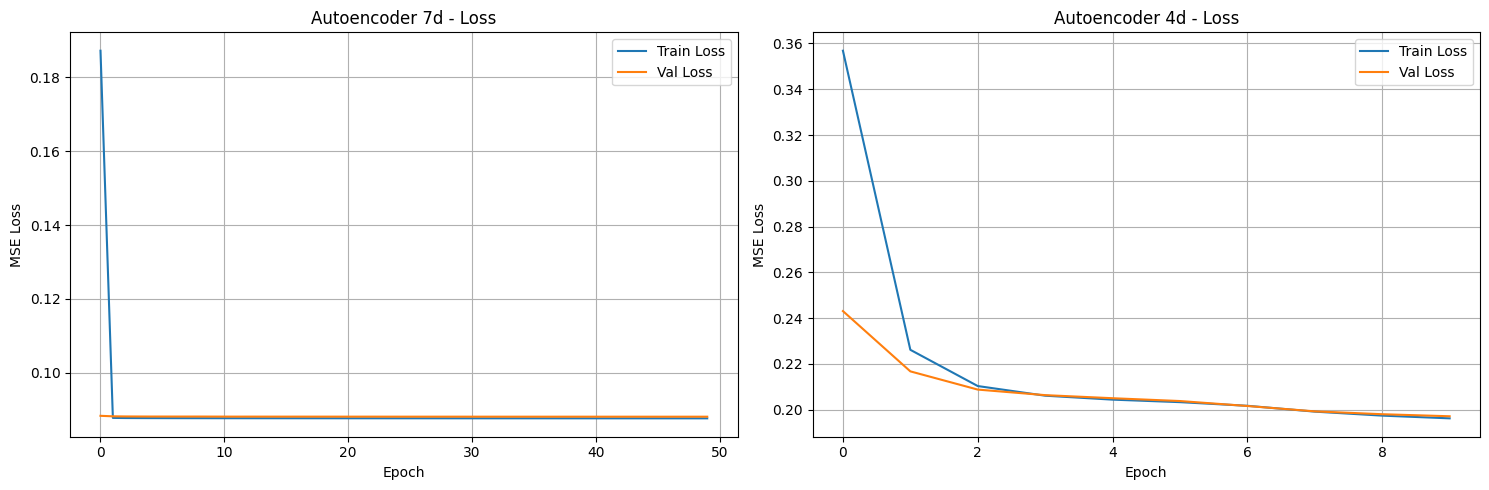

  Plot saved: /content/drive/MyDrive/mbti-tune/models/autoencoder_training_history.png


In [7]:
# ============================================
# 6. PLOT TRAINING HISTORY
# ============================================

print("\n" + "="*50)
print("6. PLOTTING TRAINING HISTORY")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, dim in enumerate([7, 4]):
    history = history_dict[dim]
    ax = axes[idx]

    ax.plot(history.history['loss'], label='Train Loss')
    ax.plot(history.history['val_loss'], label='Val Loss')
    ax.set_title(f'Autoencoder {dim}d - Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
# plt.savefig(f'{MODELS_PATH}/autoencoder_training_history.png', dpi=150)
plt.show()
print(f"  Plot saved: {MODELS_PATH}/autoencoder_training_history.png")

In [8]:
# ============================================
# 7. EXTRACT FEATURES FOR CLASSIFIER
# ============================================

print("\n" + "="*50)
print("7. EXTRACTING FEATURES FOR CLASSIFIER")
print("="*50)

# Extract features for both compression sizes
encoded_features = {}

for dim in [7, 4]:
    encoder = encoders[dim]

    # Extract features from MBTI data
    X_mbti_encoded = encoder.predict(X_mbti, verbose=0)
    encoded_features[dim] = X_mbti_encoded

    print(f"\nAutoencoder {dim}d - Encoded MBTI features:")
    print(f"  Shape: {X_mbti_encoded.shape}")
    print(f"  Feature range: [{X_mbti_encoded.min():.4f}, {X_mbti_encoded.max():.4f}]")
    print(f"  Mean: {X_mbti_encoded.mean():.4f}")
    print(f"  Std: {X_mbti_encoded.std():.4f}")

    # Save encoded features
    save_path = f'{CLEANED_PATH}/classifier/X_mbti_encoded_{dim}d.npy'
    np.save(save_path, X_mbti_encoded)
    print(f"  Saved: {save_path}")


7. EXTRACTING FEATURES FOR CLASSIFIER

Autoencoder 7d - Encoded MBTI features:
  Shape: (4201, 7)
  Feature range: [0.6921, 8.3277]
  Mean: 1.8692
  Std: 0.5995
  Saved: /content/drive/MyDrive/mbti-tune/data/cleaned/classifier/X_mbti_encoded_7d.npy

Autoencoder 4d - Encoded MBTI features:
  Shape: (4201, 4)
  Feature range: [0.5429, 18.8567]
  Mean: 2.3279
  Std: 0.8331
  Saved: /content/drive/MyDrive/mbti-tune/data/cleaned/classifier/X_mbti_encoded_4d.npy


In [9]:
# ============================================
# 8. COMPARE AUTOENCODER PERFORMANCE
# ============================================

print("\n" + "="*50)
print("8. COMPARING AUTOENCODER PERFORMANCE")
print("="*50)

# Create comparison table
comparison_data = []
for dim in [7, 4]:
    results = evaluation_results[dim]
    comparison_data.append({
        'Encoding Dim': dim,
        'MSE': results['mse'],
        'MAE': results['mae'],
        'Compression Ratio': f"{input_dim}/{dim} = {input_dim/dim:.1f}x",
        'Parameters': autoencoders[dim].count_params()
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nAutoencoder Performance Comparison:")
print(comparison_df.to_string(index=False))


8. COMPARING AUTOENCODER PERFORMANCE

Autoencoder Performance Comparison:
 Encoding Dim      MSE      MAE Compression Ratio  Parameters
            7 0.088053 0.201945       10/7 = 1.4x         305
            4 0.242450 0.356150       10/4 = 2.5x         254



9. VISUALIZING ENCODED FEATURES

Reducing dimensions with t-SNE...


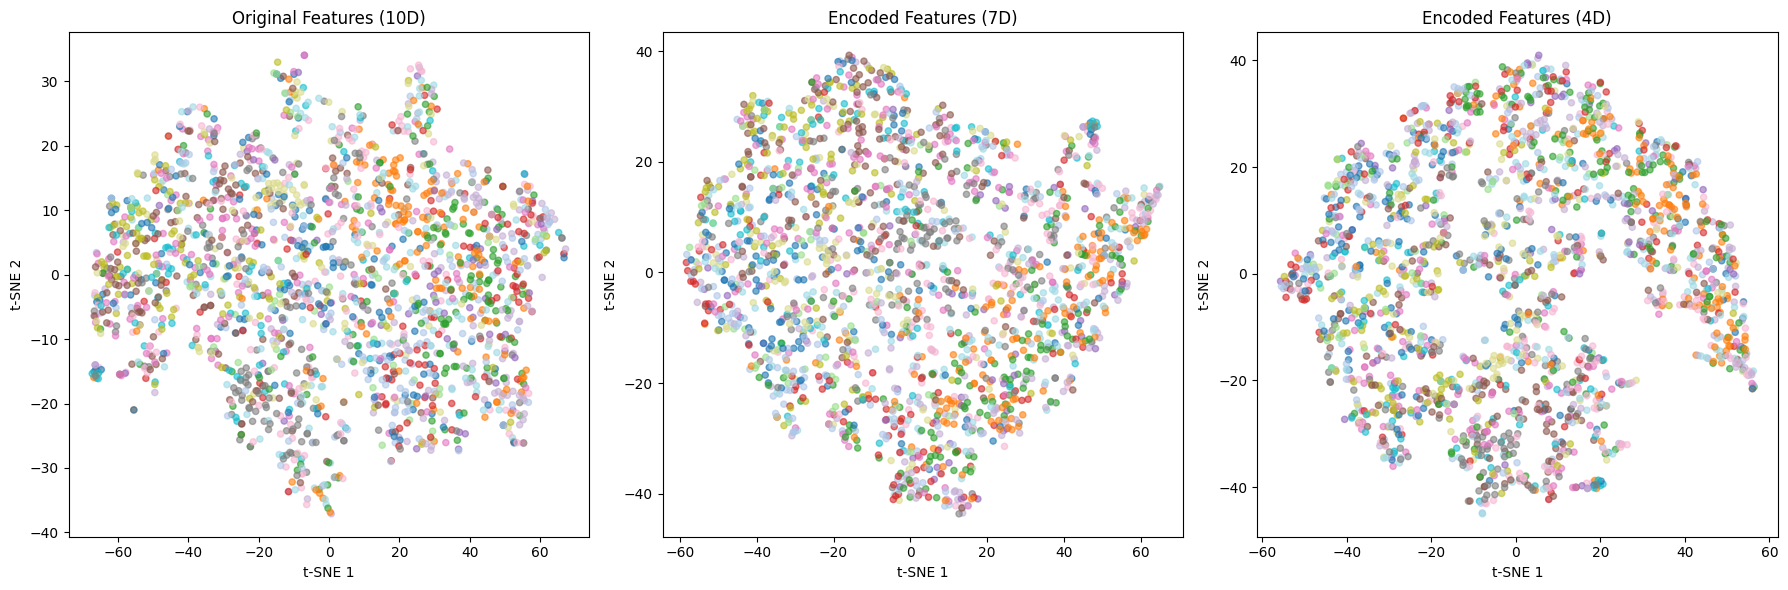

  Visualization saved: /content/drive/MyDrive/mbti-tune/models/encoded_features_visualization.png


In [10]:
# ============================================
# 9. VISUALIZE ENCODED FEATURES
# ============================================

print("\n" + "="*50)
print("9. VISUALIZING ENCODED FEATURES")
print("="*50)

try:
    # Use t-SNE to visualize encoded features
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Original features (10D)
    print("\nReducing dimensions with t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)

    # Sample for visualization (to avoid long computation)
    sample_size = min(2000, X_mbti.shape[0])
    idx_sample = np.random.choice(X_mbti.shape[0], sample_size, replace=False)

    # Original features
    X_sample_original = X_mbti[idx_sample]
    X_tsne_original = tsne.fit_transform(X_sample_original)

    ax = axes[0]
    scatter = ax.scatter(X_tsne_original[:, 0], X_tsne_original[:, 1],
                         c=pd.Categorical(y_mbti[idx_sample]).codes,
                         cmap='tab20', alpha=0.6, s=20)
    ax.set_title('Original Features (10D)')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

    # Encoded features (7D)
    X_sample_7d = encoded_features[7][idx_sample]
    X_tsne_7d = tsne.fit_transform(X_sample_7d)

    ax = axes[1]
    scatter = ax.scatter(X_tsne_7d[:, 0], X_tsne_7d[:, 1],
                         c=pd.Categorical(y_mbti[idx_sample]).codes,
                         cmap='tab20', alpha=0.6, s=20)
    ax.set_title('Encoded Features (7D)')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

    # Encoded features (4D)
    X_sample_4d = encoded_features[4][idx_sample]
    X_tsne_4d = tsne.fit_transform(X_sample_4d)

    ax = axes[2]
    scatter = ax.scatter(X_tsne_4d[:, 0], X_tsne_4d[:, 1],
                         c=pd.Categorical(y_mbti[idx_sample]).codes,
                         cmap='tab20', alpha=0.6, s=20)
    ax.set_title('Encoded Features (4D)')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

    plt.tight_layout()
    # plt.savefig(f'{MODELS_PATH}/encoded_features_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Visualization saved: {MODELS_PATH}/encoded_features_visualization.png")

except Exception as e:
    print(f"   Could not create t-SNE visualization: {e}")



In [11]:
# ============================================
# 10. SAVE ENCODED FEATURES FOR CLASSIFIER
# ============================================

print("\n" + "="*50)
print("10. PREPARING DATA FOR CLASSIFIER TRAINING")
print("="*50)

# Also encode the 1M and 110K datasets for potential use
for dim in [7, 4]:
    encoder = encoders[dim]

    # Encode 1M
    X_1m_encoded = encoder.predict(X_1m, verbose=0)
    np.save(f'{CLEANED_PATH}/autoencoder/X_1m_encoded_{dim}d.npy', X_1m_encoded)

    # Encode 110K
    X_110k_encoded = encoder.predict(X_110k, verbose=0)
    np.save(f'{CLEANED_PATH}/autoencoder/X_110k_encoded_{dim}d.npy', X_110k_encoded)

    print(f"\n{dim}d autoencoder - Encoded all datasets:")
    print(f"  1M:    {X_1m_encoded.shape}")
    print(f"  110K:  {X_110k_encoded.shape}")
    print(f"  MBTI:  {encoded_features[dim].shape}")




10. PREPARING DATA FOR CLASSIFIER TRAINING

7d autoencoder - Encoded all datasets:
  1M:    (1159764, 7)
  110K:  (114000, 7)
  MBTI:  (4201, 7)

4d autoencoder - Encoded all datasets:
  1M:    (1159764, 4)
  110K:  (114000, 4)
  MBTI:  (4201, 4)


In [12]:
# ============================================
# 11. FINAL SUMMARY
# ============================================

print("\n" + "="*80)
print("AUTOENCODER TRAINING COMPLETE!")
print("="*80)

print(f"""
SUMMARY:
========

AUTOENCODER MODELS:
─────────────────
1. 7D Autoencoder: {input_dim} → 7 → {input_dim}
   - Parameters: {autoencoders[7].count_params():,}
   - Test MSE: {evaluation_results[7]['mse']:.6f}
   - Saved: models/autoencoder_7d.h5

2. 4D Autoencoder: {input_dim} → 4 → {input_dim}
   - Parameters: {autoencoders[4].count_params():,}
   - Test MSE: {evaluation_results[4]['mse']:.6f}
   - Saved: models/autoencoder_4d.h5

ENCODED FEATURES FOR CLASSIFIER:
────────────────────────────────
1. 7D Features:
   - MBTI: {CLEANED_PATH}/classifier/X_mbti_encoded_7d.npy
   - 1M:   {CLEANED_PATH}/autoencoder/X_1m_encoded_7d.npy
   - 110K: {CLEANED_PATH}/autoencoder/X_110k_encoded_7d.npy

2. 4D Features:
   - MBTI: {CLEANED_PATH}/classifier/X_mbti_encoded_4d.npy
   - 1M:   {CLEANED_PATH}/autoencoder/X_1m_encoded_4d.npy
   - 110K: {CLEANED_PATH}/autoencoder/X_110k_encoded_4d.npy

LABELS:
───────
- y_mbti.npy: {CLEANED_PATH}/classifier/y_mbti.npy

NEXT STEPS FOR CLASSIFIER:
==========================
1. Load encoded features:
   X_7d = np.load('{CLEANED_PATH}/classifier/X_mbti_encoded_7d.npy')
   X_4d = np.load('{CLEANED_PATH}/classifier/X_mbti_encoded_4d.npy')
   y = np.load('{CLEANED_PATH}/classifier/y_mbti.npy', allow_pickle=True)

2. Train classifiers:
   - Random Forest on 7D features
   - Random Forest on 4D features
   - Neural Network on 7D features
   - Neural Network on 4D features

3. Compare performance to:
   - Using original 10D features
   - Both autoencoder versions (7D vs 4D)

4. Evaluate which compression works best!

MODEL FILES:
────────────
- {MODELS_PATH}/autoencoder_7d.h5
- {MODELS_PATH}/autoencoder_4d.h5
- {MODELS_PATH}/encoder_7d.h5
- {MODELS_PATH}/encoder_4d.h5
- {MODELS_PATH}/autoencoder_training_history.png
- {MODELS_PATH}/encoded_features_visualization.png
""")

print("="*80)
print("READY FOR CLASSIFIER TRAINING!")
print("="*80)


AUTOENCODER TRAINING COMPLETE!

SUMMARY:

AUTOENCODER MODELS:
─────────────────
1. 7D Autoencoder: 10 → 7 → 10
   - Parameters: 305
   - Test MSE: 0.088053
   - Saved: models/autoencoder_7d.h5

2. 4D Autoencoder: 10 → 4 → 10
   - Parameters: 254
   - Test MSE: 0.242450
   - Saved: models/autoencoder_4d.h5

ENCODED FEATURES FOR CLASSIFIER:
────────────────────────────────
1. 7D Features:
   - MBTI: /content/drive/MyDrive/mbti-tune/data/cleaned/classifier/X_mbti_encoded_7d.npy
   - 1M:   /content/drive/MyDrive/mbti-tune/data/cleaned/autoencoder/X_1m_encoded_7d.npy
   - 110K: /content/drive/MyDrive/mbti-tune/data/cleaned/autoencoder/X_110k_encoded_7d.npy

2. 4D Features:
   - MBTI: /content/drive/MyDrive/mbti-tune/data/cleaned/classifier/X_mbti_encoded_4d.npy
   - 1M:   /content/drive/MyDrive/mbti-tune/data/cleaned/autoencoder/X_1m_encoded_4d.npy
   - 110K: /content/drive/MyDrive/mbti-tune/data/cleaned/autoencoder/X_110k_encoded_4d.npy

LABELS:
───────
- y_mbti.npy: /content/drive/MyDriv